In [1]:
import pandas as pd 

In [2]:
df=pd.read_csv('Data/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [5]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', pd.NA)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [7]:
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'Contract']]

,tenure,MonthlyCharges,Contract
488,0,52.55,Two year
753,0,20.25,Two year
936,0,80.85,Two year
1082,0,25.75,Two year
1340,0,56.05,Two year
3331,0,19.85,Two year
3826,0,25.35,Two year
4380,0,20.00,Two year
5218,0,19.70,One year
6670,0,73.35,Two year


In [8]:
df = df.dropna(subset=['TotalCharges'])
df.shape

(7032, 21)

## 📌 Insight 1 — Contract Type vs Churn

Churn rate varies drastically by contract type: 42.7% for month-to-month, 
11.3% for one-year, and only 2.8% for two-year contracts. 
This suggests that long-term commitment is the strongest retention factor. 
The business should incentivize customers to switch to longer contracts 
through discounts or added benefits for annual plans.

In [9]:
df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


## 📌 Insight 2 — StreamingTV vs Churn

StreamingTV shows almost no impact on churn: 33.5% churn rate 
without streaming vs 30.1% with streaming. 
Customers with no internet service have significantly lower churn (7.4%), 
likely because they use fewer services overall and are less price-sensitive.

In [10]:
df.groupby('StreamingTV')['Churn'].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
StreamingTV,,
No,66.464934,33.535066
No internet service,92.565789,7.434211
Yes,69.885313,30.114687


## 📌 Insight 3 — Tenure & MonthlyCharges vs Churn

Customers who churned had significantly shorter tenure (18 vs 38 months) 
and higher monthly charges ($74 vs $61). This suggests that price sensitivity 
is a key churn driver — customers leave not because of poor service, 
but because they find the cost too high relative to perceived value.

Recommendations:
- Introduce loyalty discounts for customers after 12+ months
- Offer price-locked plans for long-term subscribers
- Provide added features or benefits instead of direct discounts 
  to maintain revenue while improving retention

In [11]:
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.650010,61.307408,2555.344141
Yes,17.979133,74.441332,1531.796094


## 📌 Insight 4 — Payment Method vs Churn

Customers paying via electronic check churn at 45.3% — 
nearly 3x higher than automatic payment methods (15-17%).
Manual payment creates a monthly decision point where customers 
can reconsider their subscription.

Recommendation: actively encourage customers to switch 
to automatic payments — even a small incentive (discount, bonus) 
would significantly reduce churn risk.

In [12]:
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


## 📌 Insight 5 — Senior Citizens vs Churn

Senior customers churn at 41.7% compared to 23.7% for non-senior customers.
This may be linked to price sensitivity, complexity of services, 
or lack of tailored support for older users.

Recommendation: introduce a senior-friendly plan with simplified 
services, lower price point, or dedicated support channel. 
This segment may need a different value proposition rather 
than the standard offering.

In [13]:
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


## 📌 Insight 6 — Partner vs Churn

Customers with a partner churn at 19.7% vs 33% for single customers.
This suggests that customers with family responsibilities 
are more stable and price-consistent.

Recommendation: introduce family or shared plans similar to 
streaming services — this naturally attracts the lower-churn 
segment and increases switching costs for existing customers.

In [14]:
df.groupby('Partner')['Churn'].value_counts(normalize=True).unstack() * 100

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


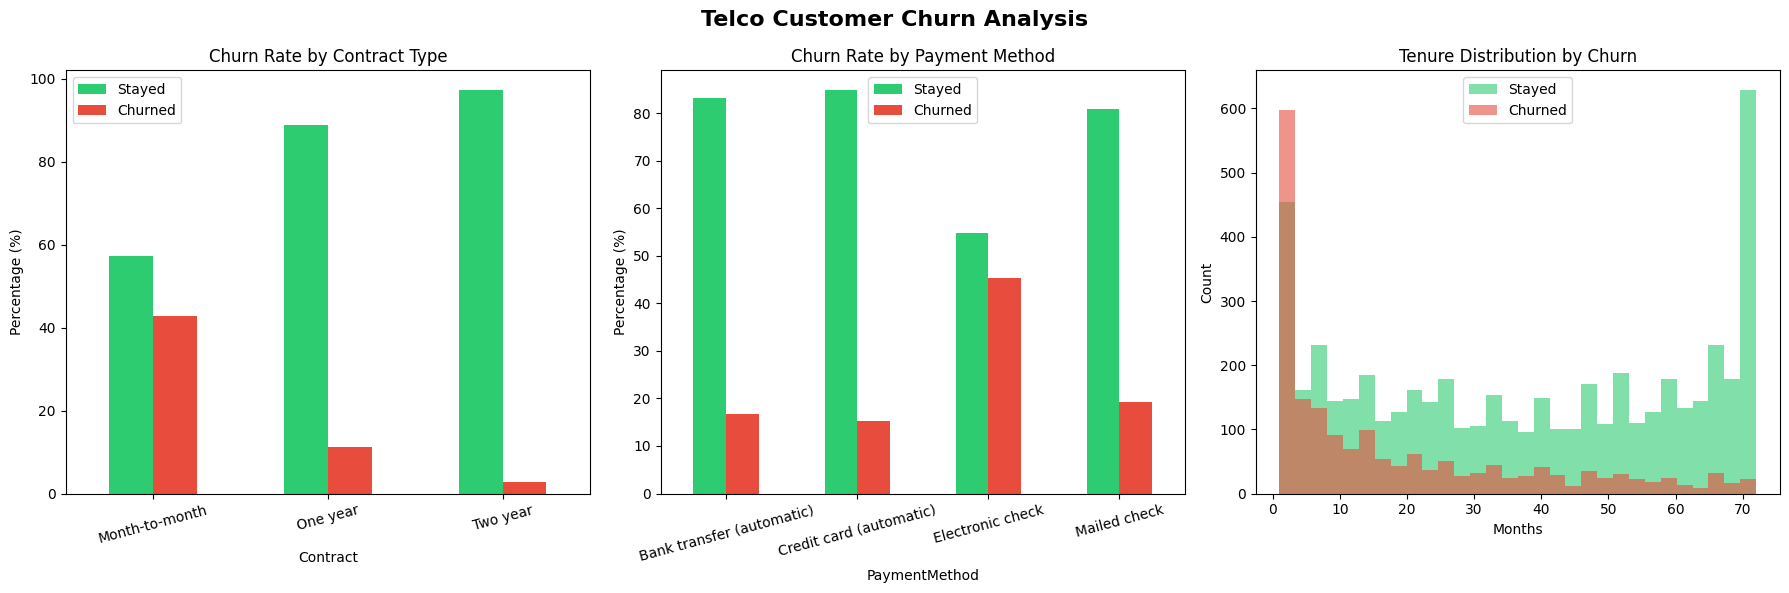

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Telco Customer Churn Analysis', fontsize=16, fontweight='bold')

# 1. Contract vs Churn
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
contract_churn.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], rot=15)
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(['Stayed', 'Churned'])

# 2. Payment Method vs Churn
payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100
payment_churn.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], rot=15)
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['Stayed', 'Churned'])

# 3. Tenure distribution
axes[2].hist(df[df['Churn']=='No']['tenure'], bins=30, alpha=0.6, color='#2ecc71', label='Stayed')
axes[2].hist(df[df['Churn']=='Yes']['tenure'], bins=30, alpha=0.6, color='#e74c3c', label='Churned')
axes[2].set_title('Tenure Distribution by Churn')
axes[2].set_xlabel('Months')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('images/churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()